<a href="https://colab.research.google.com/github/elizmunoz-bui/one-fracture-detection-cv/blob/main/redicci%C3%B3n_de_Fracturas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PREDICCIÓN DE FRACTURAS CON REDES NEURONALES PROFUNDAS

# **1.** Librerias y carga de datos

In [ ]:
from google.colab import drive
import os
import cv2
import numpy as np
from tqdm import tqdm
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import load_model
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix,precision_score,recall_score,f1_score,accuracy_score,classification_report,roc_auc_score)
drive.mount('/content/drive')

# Rutas y configuración de la limpieza
ruta_base = '/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 '
ruta_dataset = os.path.join(ruta_base, 'Bone_Fracture_Binary_Classification')
ruta_guardado = os.path.join(ruta_base, 'datos_procesados_fracturas.npz')

categorias = ['not fractured', 'fractured']
IMG_SIZE = 128


Mounted at /content/drive


# **2.** Función de procesamiento de datos

In [ ]:

def cargar_y_procesar(carpeta_set):
    X, Y = [], []
    ruta_set = os.path.join(ruta_dataset, carpeta_set)

    if not os.path.exists(ruta_set):
        return None, None

    for categoria in categorias:
        ruta_categoria = os.path.join(ruta_set, categoria)
        etiqueta = categorias.index(categoria)

        if os.path.exists(ruta_categoria):
            imagenes = os.listdir(ruta_categoria)
            for img_nombre in tqdm(imagenes, desc=f"Procesando {carpeta_set} - {categoria}"):
                ruta_img = os.path.join(ruta_categoria, img_nombre)
                img = cv2.imread(ruta_img, cv2.IMREAD_GRAYSCALE) # Limpieza a blanco y negro

                if img is not None:
                    img_redim = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) # Filtro de tamaño
                    X.append(img_redim)
                    Y.append(etiqueta)

    X, Y = np.array(X), np.array(Y)

    # Normalización y aplanado
    if len(X) > 0:
        X_aplanado = (X.astype('float32') / 255.0).reshape(X.shape[0], -1)
        Y_one_hot = to_categorical(Y, num_classes=2)
        return X_aplanado, Y_one_hot
    return None, None

# 4. Ejecución del proceso
print("--- INICIANDO LIMPIEZA Y PREPROCESAMIENTO ---")
x_train, y_train = cargar_y_procesar('train')
x_val, y_val = cargar_y_procesar('val')
x_test, y_test = cargar_y_procesar('test')

# 5. Guardado del archivo definitivo
if x_train is not None:
    print("\nComprimiendo y guardando datos limpios en Drive...")
    np.savez_compressed(
        ruta_guardado,
        x_train=x_train, y_train=y_train,
        x_val=x_val, y_val=y_val,
        x_test=x_test, y_test=y_test
    )
    print(f"✅ ¡Datos guardados exitosamente en:\n{ruta_guardado}")
else:
    print("❌ Error: No se encontraron imágenes.")

--- INICIANDO LIMPIEZA Y PREPROCESAMIENTO ---


Procesando test - fractured: 100%|██████████| 238/238 [01:12<00:00,  3.29it/s]



Comprimiendo y guardando datos limpios en Drive...
✅ ¡Datos guardados exitosamente en:
/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 /datos_procesados_fracturas.npz


## FUNCIÓN PARA EVALUAR EL MODELO

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, roc_curve

def evaluar_modelo(model, x_test, y_test, nombre):
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    print(f"\n🔍 Evaluación - {nombre}")
    print(classification_report(y_true, y_pred))

    # F1 Score
    f1 = f1_score(y_true, y_pred)
    print(f"F1 Score: {f1:.4f}")

    # ROC AUC
    roc_auc = roc_auc_score(y_true, y_pred_probs[:,1])
    print(f"ROC AUC: {roc_auc:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.show()

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:,1])
    plt.plot(fpr, tpr)
    plt.title(f"Curva ROC - {nombre}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.grid()
    plt.show()

## Descripción del dataset
Este conjunto de datos comprende imágenes radiográficas de fracturas y no fracturas que abarcan todas las regiones anatómicas del cuerpo, incluyendo extremidades inferiores, extremidades superiores, región lumbar, caderas, rodillas, etc.

## Contenido del conjunto de datos:
Este conjunto de datos contiene 10.580 imágenes radiográficas (rayos X).

Número de imágenes de datos de entrenamiento
: 9246

Número de imágenes de datos de validación
: 828

Número de imágenes de prueba
: 506

In [ ]:
# para asegurar que los datos estan en drive
drive.mount('/content/drive')

ruta_datos_limpios = '/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 /datos_procesados_fracturas.npz'

print("Cargando datos preprocesados desde Drive...")

if os.path.exists(ruta_datos_limpios):

    datos_cacheados = np.load(ruta_datos_limpios)

    # Asignación de variables matemáticas
    x_train = datos_cacheados['x_train']
    y_train = datos_cacheados['y_train']
    x_val = datos_cacheados['x_val']
    y_val = datos_cacheados['y_val']
    x_test = datos_cacheados['x_test']
    y_test = datos_cacheados['y_test']

    print("✅ ¡Datos limpios cargados al instante!")
    print(f"-> Imágenes para entrenar: {x_train.shape[0]}")
    print(f"-> Imágenes para validar: {x_val.shape[0]}")
    print(f"-> Imágenes para probar: {x_test.shape[0]}")
else:
    print("❌ Error: No se encontró el archivo .npz en tu Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cargando datos preprocesados desde Drive...
✅ ¡Datos limpios cargados al instante!
-> Imágenes para entrenar: 9246
-> Imágenes para validar: 829
-> Imágenes para probar: 506


# **3.** Visualización de imágenes

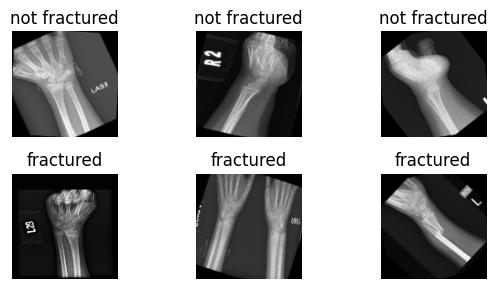

In [ ]:
def visualizar_imagenes(x, y, categorias, img_size=128, n=6):
    plt.figure(figsize=(6, 3))

    #  índices aleatorios
    indices = np.random.choice(len(x), n, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(2, n//2, i+1)

        img = x[idx]

        if len(img.shape) == 1:
            img = img.reshape(img_size, img_size)

        if len(img.shape) == 3 and img.shape[-1] == 1:
            img = img.squeeze()

        plt.imshow(img, cmap='gray')
        plt.title(categorias[np.argmax(y[idx])])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecutar
visualizar_imagenes(x_train, y_train, categorias)

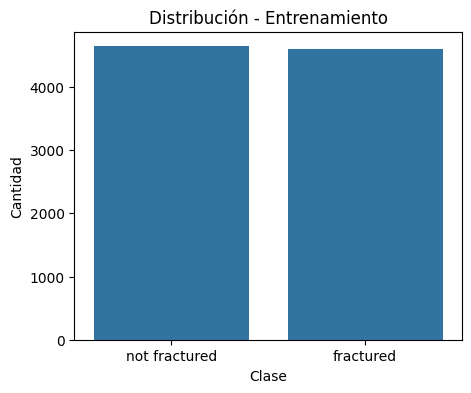

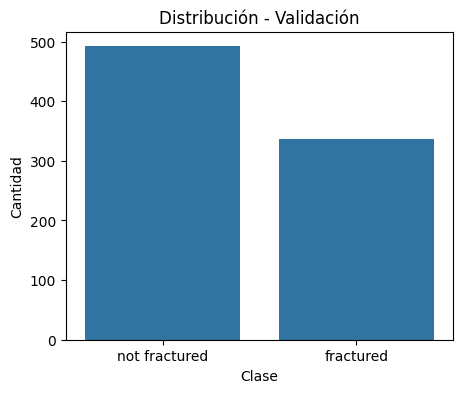

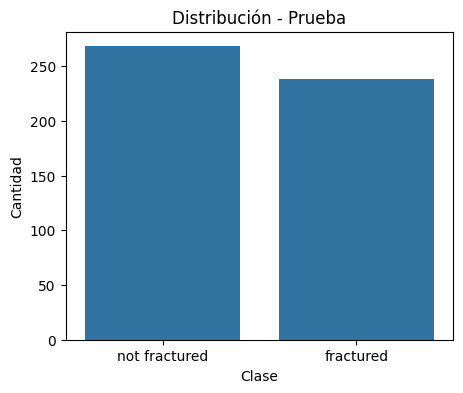

In [ ]:
def plot_distribucion(y, categorias, titulo):
    labels = np.argmax(y, axis=1)

    plt.figure(figsize=(5,4))
    sns.countplot(x=labels)
    plt.xticks([0,1], categorias)
    plt.title(titulo)
    plt.xlabel("Clase")
    plt.ylabel("Cantidad")
    plt.show()

# Train
plot_distribucion(y_train, categorias, "Distribución - Entrenamiento")

# Validación
plot_distribucion(y_val, categorias, "Distribución - Validación")

# Test
plot_distribucion(y_test, categorias, "Distribución - Prueba")


# **4.** MODELOS

## MODELO 1

In [ ]:
# --- 1. CONSTRUCCIÓN DEL MODELO 1 ---
#4 capas (arquitectura tipo embudo)

input_dim = x_train.shape[1]

model_1 = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(2, activation='softmax')
])

# --- 2. COMPILACIÓN ---
optimizador = Adam(learning_rate=0.001)

model_1.compile(
    optimizer=optimizador,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 3. ENTRENAMIENTO  ---
parada_temprana = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("¡Iniciando el entrenamiento de la Red Neuronal Profunda!")


historial_modelo_1 = model_1.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_val, y_val),
    epochs=35,
    batch_size=32,
    callbacks=[parada_temprana],
    verbose=1
)

print("\n¡Entrenamiento finalizado !")

# --- 4. AUTO-GUARDADO
ruta_guardado = '/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 /modelo_1_fracturas.keras'
model_1.save(ruta_guardado)
print(f"💾 Modelo asegurado y guardado en tu Drive:\n{ruta_guardado}")

¡Iniciando el entrenamiento de la Red Neuronal Profunda!
Epoch 1/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 53s 171ms/step - accuracy: 0.7068 - loss: 0.6233 - val_accuracy: 0.7961 - val_loss: 0.4909
Epoch 2/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 63s 219ms/step - accuracy: 0.8206 - loss: 0.4058 - val_accuracy: 0.7973 - val_loss: 0.4862
Epoch 3/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 73s 190ms/step - accuracy: 0.8651 - loss: 0.3221 - val_accuracy: 0.8335 - val_loss: 0.4392
Epoch 4/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 78s 177ms/step - accuracy: 0.8870 - loss: 0.2827 - val_accuracy: 0.8589 - val_loss: 0.3611
Epoch 5/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 55s 190ms/step - accuracy: 0.8958 - loss: 0.2595 - val_accuracy: 0.8818 - val_loss: 0.3470
Epoch 6/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 51s 178ms/step - accuracy: 0.9121 - loss: 0.2200 - val_accuracy: 0.8926 - val_loss: 0.3433
Epoch 7/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 52s 181ms/step - accuracy: 0.9185 - loss: 0.2112 - val_accuracy: 0.8926 - val_loss: 0.2684
Epoch 8/35
289/289 ━━━━━━━

Evaluando el modelo con los datos de Prueba (Test)...

Exactitud (Accuracy) en Prueba: 91.70%
Pérdida (Loss) en Prueba: 0.2502

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
--------------------------------------------------
REPORTE DE CLASIFICACIÓN
--------------------------------------------------
                precision    recall  f1-score   support

      Sano (0)       0.95      0.89      0.92       268
Fracturado (1)       0.89      0.95      0.91       238

      accuracy                           0.92       506
     macro avg       0.92      0.92      0.92       506
  weighted avg       0.92      0.92      0.92       506



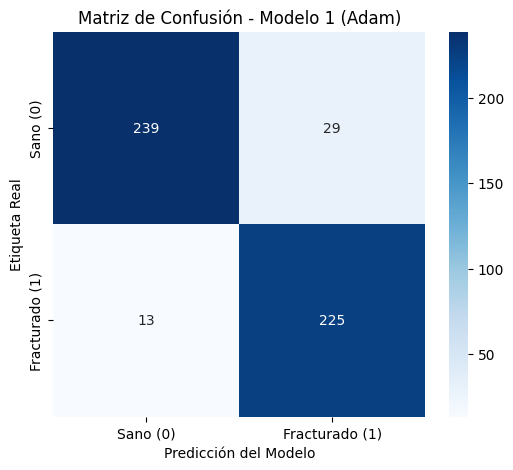

In [ ]:
print("Evaluando el modelo con los datos de Prueba (Test)...")

# 1. Evaluación
loss_test, acc_test = model_1.evaluate(x_test, y_test, verbose=0)
print(f"\nExactitud (Accuracy) en Prueba: {acc_test * 100:.2f}%")
print(f"Pérdida (Loss) en Prueba: {loss_test:.4f}\n")

# 2. Predicciones
y_pred_probs = model_1.predict(x_test)
y_pred_clases = np.argmax(y_pred_probs, axis=1)
y_test_clases = np.argmax(y_test, axis=1)

# 3. Reporte de Clasificación (Precisión y Recall)
print("-" * 50)
print("REPORTE DE CLASIFICACIÓN")
print("-" * 50)
nombres_clases = ['Sano (0)', 'Fracturado (1)']
print(classification_report(y_test_clases, y_pred_clases, target_names=nombres_clases))

# 4. Matriz de Confusión
cm = confusion_matrix(y_test_clases, y_pred_clases)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Modelo 1 (Adam)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


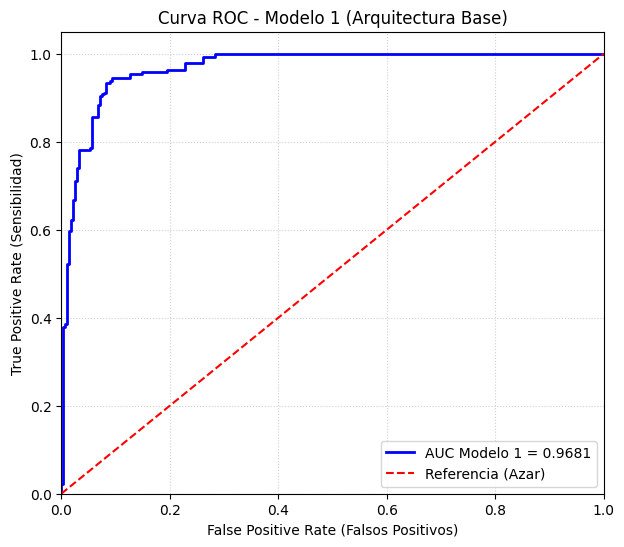

✅ Análisis completado. El AUC del Modelo 1 es: 0.9681


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. CARGA MODELO GUARDADO
ruta_guardado = '/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 /modelo_1_fracturas.keras'
model_1 = load_model(ruta_guardado)

# 2. OBTENCIÓN DE PREDICCIONES
y_pred_prob = model_1.predict(x_test)
y_pred_prob_pos = y_pred_prob[:, 1]
y_true_clases = np.argmax(y_test, axis=1)

# 3. CÁLCULO DE MÉTRICAS ROC
fpr, tpr, thresholds = roc_curve(y_true_clases, y_pred_prob_pos)
roc_auc = auc(fpr, tpr)

# 4. GRAFICACIÓN
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC Modelo 1 = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Referencia (Azar)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (Falsos Positivos)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curva ROC - Modelo 1 (Arquitectura Base)")
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Análisis completado. El AUC del Modelo 1 es: {roc_auc:.4f}")

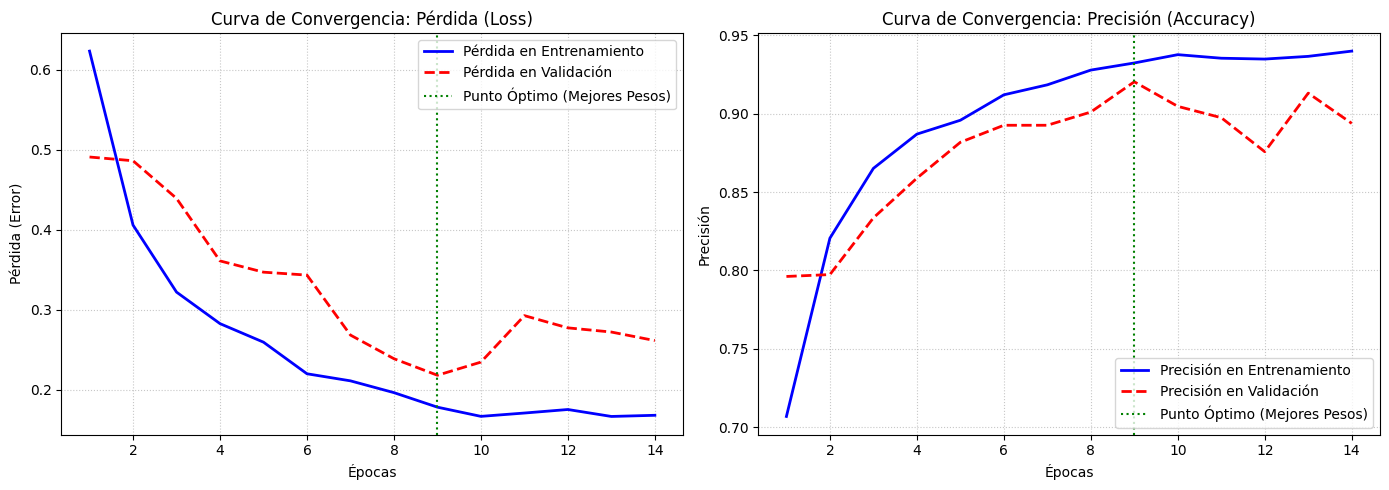

In [ ]:
# Extracción de los datos
acc = historial_modelo_1.history['accuracy']
val_acc = historial_modelo_1.history['val_accuracy']
loss = historial_modelo_1.history['loss']
val_loss = historial_modelo_1.history['val_loss']

epocas = range(1, len(acc) + 1)

# Configuración del tamaño
plt.figure(figsize=(14, 5))

#Gráfica 1: Curva de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(epocas, loss, 'b-', linewidth=2, label='Pérdida en Entrenamiento')
plt.plot(epocas, val_loss, 'r--', linewidth=2, label='Pérdida en Validación')
plt.axvline(x=len(acc)-5, color='green', linestyle=':', label='Punto Óptimo (Mejores Pesos)')
plt.title('Curva de Convergencia: Pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Error)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

#Gráfica 2: Curva de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epocas, acc, 'b-', linewidth=2, label='Precisión en Entrenamiento')
plt.plot(epocas, val_acc, 'r--', linewidth=2, label='Precisión en Validación')
plt.axvline(x=len(acc)-5, color='green', linestyle=':', label='Punto Óptimo (Mejores Pesos)')
plt.title('Curva de Convergencia: Precisión (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)


plt.tight_layout()
plt.show()

## MODELO 2

In [ ]:
from tensorflow.keras import regularizers
input_dim = x_train.shape[1]

#  MODELO 2 (Con L2 y Dropout)
reg_l2 = regularizers.l2(0.0001)

model_2 = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(256, activation='relu', kernel_regularizer=reg_l2),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu', kernel_regularizer=reg_l2),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(64, activation='relu', kernel_regularizer=reg_l2),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(2, activation='softmax')
])

# 2. COMPILACIÓN
optimizador_2 = Adam(learning_rate=0.0001)

model_2.compile(
    optimizer=optimizador_2,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. ENTRENAMIENTO
parada_temprana_2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Iniciando el entrenamiento del Modelo 2 (Arquitectura con Regularización L2)!")

historial_modelo_2 = model_2.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_val, y_val),
    epochs=35,
    batch_size=32,
    callbacks=[parada_temprana_2],
    verbose=1
)

print("\n ¡Entrenamiento del Modelo 2 finalizado!")

# 4. AUTO-GUARDADO
ruta_guardado_2 = '/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 /modelo_2_L2_fracturas.keras'

model_2.save(ruta_guardado_2)
print(f"Modelo 2 asegurado y guardado en:\n{ruta_guardado_2}")

Iniciando el entrenamiento del Modelo 2 (Arquitectura con Regularización L2)!
Epoch 1/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 40s 121ms/step - accuracy: 0.6565 - loss: 0.8300 - val_accuracy: 0.7431 - val_loss: 0.6512
Epoch 2/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 32s 91ms/step - accuracy: 0.7205 - loss: 0.6833 - val_accuracy: 0.7841 - val_loss: 0.5874
Epoch 3/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step - accuracy: 0.7600 - loss: 0.5941 - val_accuracy: 0.8347 - val_loss: 0.5630
Epoch 4/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.7856 - loss: 0.5473 - val_accuracy: 0.8094 - val_loss: 0.4944
Epoch 5/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 25s 88ms/step - accuracy: 0.8158 - loss: 0.4964 - val_accuracy: 0.8347 - val_loss: 0.5132
Epoch 6/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - accuracy: 0.8285 - loss: 0.4713 - val_accuracy: 0.8504 - val_loss: 0.4383
Epoch 7/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.8416 - loss: 0.4411 - val_accuracy: 0.8637 - val_loss: 0.4600
Epoch 8/35


✅ Modelo 2 (L2 + Dropout) cargado . 

Evaluando el Modelo 2 con los datos de Prueba (Test)...

Exactitud (Accuracy) en Prueba: 94.27%
Pérdida (Loss) en Prueba: 0.2339

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
--------------------------------------------------
REPORTE DE CLASIFICACIÓN - MODELO 2
--------------------------------------------------
                precision    recall  f1-score   support

      Sano (0)       0.95      0.94      0.95       268
Fracturado (1)       0.93      0.95      0.94       238

      accuracy                           0.94       506
     macro avg       0.94      0.94      0.94       506
  weighted avg       0.94      0.94      0.94       506



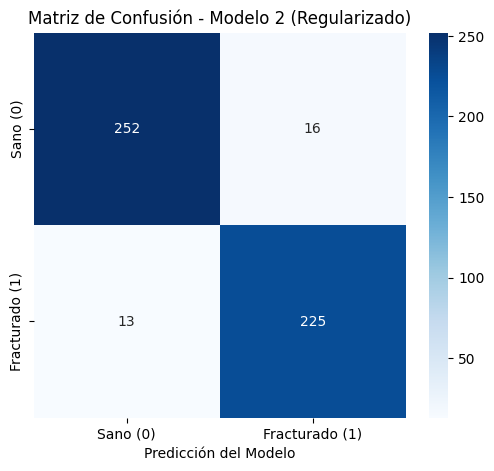

In [ ]:
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. CARGAR EL MODELO 2
ruta_modelo_2 = '/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 /modelo_2_L2_fracturas.keras'

try:
    model_2 = tf.keras.models.load_model(ruta_modelo_2)
    print(" Modelo 2 (L2 + Dropout) cargado . ")
except Exception as e:
    print(f" Hay Error al cargar el modelo: {e}")

# 2. EVALUACIÓN GENERAl
print("\nEvaluando el Modelo 2 con los datos de Prueba (Test)...")

# Evaluación global (Loss y Accuracy)
loss_test, acc_test = model_2.evaluate(x_test, y_test, verbose=0)
print(f"\nExactitud (Accuracy) en Prueba: {acc_test * 100:.2f}%")
print(f"Pérdida (Loss) en Prueba: {loss_test:.4f}\n")

# 3. PREDICCIONES Y MÉTRICAS
y_pred_probs = model_2.predict(x_test)
y_pred_clases = np.argmax(y_pred_probs, axis=1)
y_test_clases = np.argmax(y_test, axis=1)

# Reporte de Clasificación (Precisión, Sensibilidad, F1)
print("-" * 50)
print("REPORTE DE CLASIFICACIÓN - MODELO 2")
print("-" * 50)
nombres_clases = ['Sano (0)', 'Fracturado (1)']
print(classification_report(y_test_clases, y_pred_clases, target_names=nombres_clases))

# 4. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test_clases, y_pred_clases)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases,
            yticklabels=nombres_clases)

plt.title('Matriz de Confusión - Modelo 2 (Regularizado)')
plt.ylabel('')
plt.xlabel('Predicción del Modelo')
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


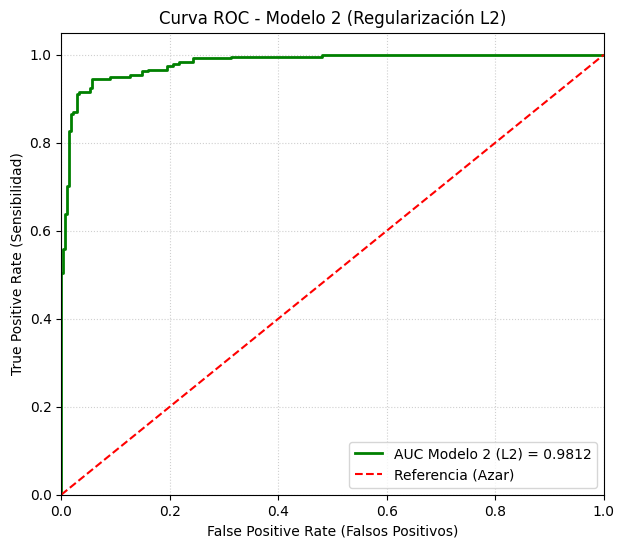

El AUC del Modelo 2 es: 0.9812


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 1. CARGAR EL MODELO 2
ruta_guardado_2 = '/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 /modelo_2_L2_fracturas.keras'
model_2 = load_model(ruta_guardado_2)

# 2. OBTENCIÓN DE PREDICCIONES
y_pred_prob_2 = model_2.predict(x_test)
y_pred_prob_pos_2 = y_pred_prob_2[:, 1]
y_true_clases = np.argmax(y_test, axis=1)

# 3. CÁLCULO DE MÉTRICAS ROC
fpr_2, tpr_2, thresholds_2 = roc_curve(y_true_clases, y_pred_prob_pos_2)
roc_auc_2 = auc(fpr_2, tpr_2)

# 4. GRAFICACIÓN
plt.figure(figsize=(7, 6))
plt.plot(fpr_2, tpr_2, color='green', lw=2, label=f"AUC Modelo 2 (L2) = {roc_auc_2:.4f}")
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Referencia (Azar)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (Falsos Positivos)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curva ROC - Modelo 2 (Regularización L2)")
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"El AUC del Modelo 2 es: {roc_auc_2:.4f}")

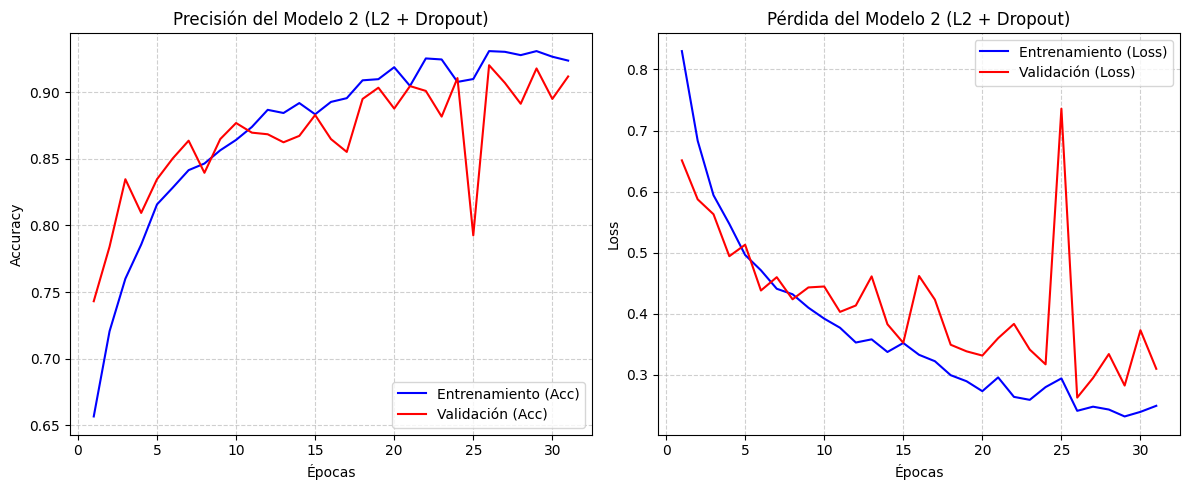

In [ ]:
import matplotlib.pyplot as plt

# 1. Extracción de datos del historial
acc = historial_modelo_2.history['accuracy']
val_acc = historial_modelo_2.history['val_accuracy']
loss = historial_modelo_2.history['loss']
val_loss = historial_modelo_2.history['val_loss']
epochs_range = range(1, len(acc) + 1)
plt.figure(figsize=(12, 5))

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento (Acc)', color='blue')
plt.plot(epochs_range, val_acc, label='Validación (Acc)', color='red')
plt.title('Precisión del Modelo 2 (L2 + Dropout)')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento (Loss)', color='blue')
plt.plot(epochs_range, val_loss, label='Validación (Loss)', color='red')
plt.title('Pérdida del Modelo 2 (L2 + Dropout)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## MODELO 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from PIL import Image

ruta_base = "/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 /Bone_Fracture_Binary_Classification"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def limpiar_imagenes_corruptas(ruta):
    eliminadas = 0
    revisadas = 0

    for root, dirs, files in os.walk(ruta):
        for archivo in files:
            ruta_imagen = os.path.join(root, archivo)

            # Filtrar solo imágenes comunes
            if archivo.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                revisadas += 1

                try:
                    # Verificación básica
                    with Image.open(ruta_imagen) as img:
                        img.verify()

                    # Verificación completa
                    with Image.open(ruta_imagen) as img:
                        img.load()

                except Exception:
                    print(f"❌ Eliminando: {ruta_imagen}")
                    os.remove(ruta_imagen)
                    eliminadas += 1

    print(f"Imágenes revisadas: {revisadas}")
    print(f"Imágenes eliminadas: {eliminadas}")
limpiar_imagenes_corruptas(ruta_base)

Imágenes revisadas: 10563
Imágenes eliminadas: 0


In [ ]:
# Preprocesamiento de las imagenes
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMG_SIZE = (128, 128)
BATCH_SIZE = 64

datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_data = datagen.flow_from_directory(
    ruta_base + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='grayscale'
)

val_data = datagen.flow_from_directory(
    ruta_base + "/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    color_mode='grayscale'
)

test_data = datagen.flow_from_directory(
    ruta_base + "/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    color_mode='grayscale'
)

Found 9240 images belonging to 2 classes.
Found 823 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [ ]:
# Red neuroanl con regularización L2
model_3 = Sequential([
    Input(shape=(128, 128, 1)),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=l2(0.0005)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.0005)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.0005)),
    Dense(32, activation='relu', kernel_regularizer=l2(0.0005)),
    Dense(1, activation='sigmoid')
])

model_1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Early Stopping con tolerancia de 5 epocas
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
# Entrenamiento del modelo
history_3 = model_3.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
from tensorflow.keras.models import load_model
import pickle

ruta_guardado = "/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1/"

modelo_L2 = load_model(ruta_guardado + "modelo_L2.h5")

with open(ruta_guardado + "history_L2.pkl", "rb") as f:
    history_L2_dict = pickle.load(f)

class History:
    def __init__(self, history):
        self.history = history

history_L2 = History(history_L2_dict)

modelo_L2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,237,827 (16.17 MB)

 Trainable params: 4,237,825 (16.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Mejor val_loss: 0.2569
Mejor val_accuracy: 0.9441
 4/13 ━━━━━━━━━━━━━━━━━━━━ 4s 473ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 547ms/step
              precision    recall  f1-score   support

No Fractured       0.96      0.90      0.93       337
   Fractured       0.93      0.97      0.95       486

    accuracy                           0.94       823
   macro avg       0.95      0.94      0.94       823
weighted avg       0.94      0.94      0.94       823



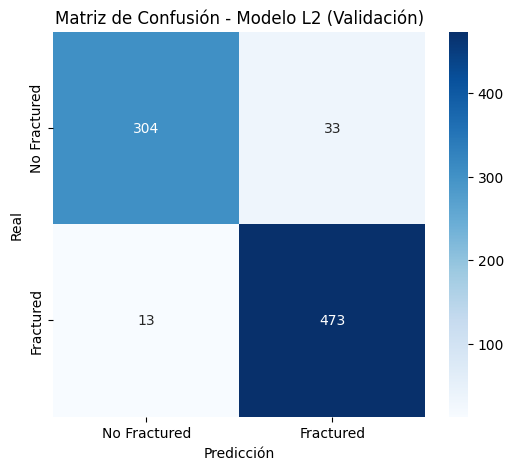

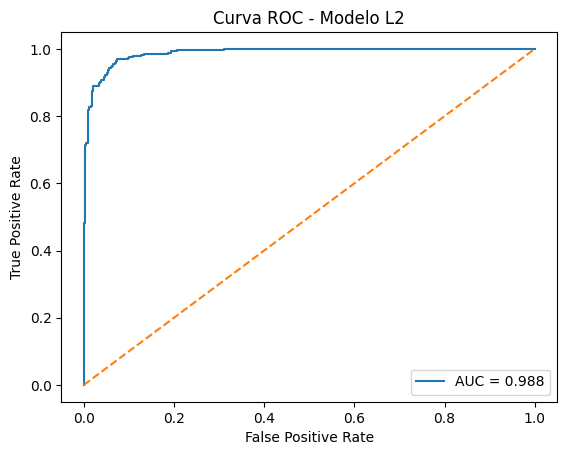

In [ ]:
from sklearn.metrics import (roc_curve, auc, precision_score, recall_score,
                             f1_score, accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

best_val_loss = np.min(history_L2.history['val_loss'])
best_val_acc = np.max(history_L2.history['val_accuracy'])
print(f"Mejor val_loss: {best_val_loss:.4f}")
print(f"Mejor val_accuracy: {best_val_acc:.4f}")

y_pred_prob = modelo_L2.predict(val_data)
y_pred_prob = y_pred_prob.ravel()

y_pred = (y_pred_prob > 0.5).astype(int)
y_true = val_data.classes

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_pred_prob)

print(classification_report(
    y_true,
    y_pred,
    target_names=['No Fractured', 'Fractured']
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fractured','Fractured'],
            yticklabels=['No Fractured','Fractured'])

plt.title("Matriz de Confusión - Modelo L2 (Validación)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo L2")
plt.legend()
plt.show()

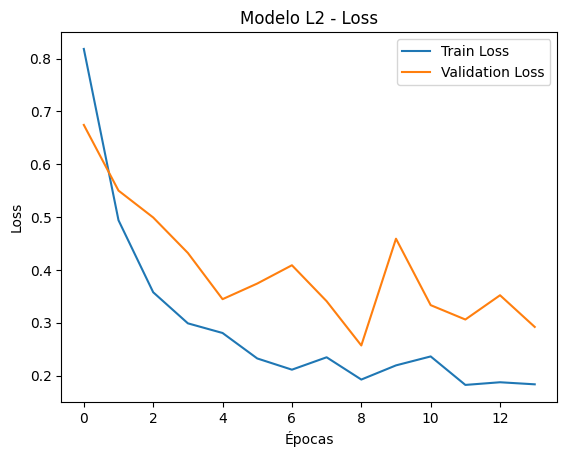

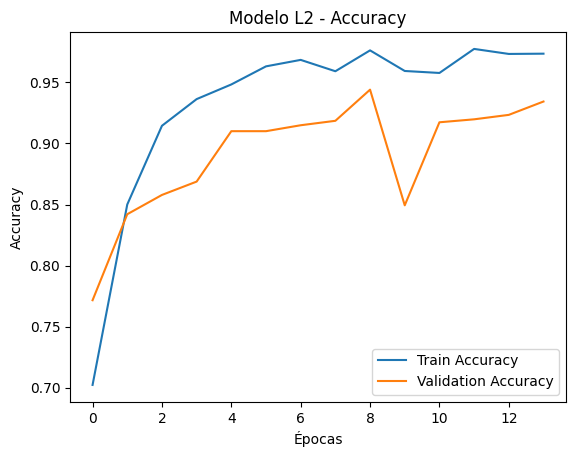

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f"{title} - Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history_L2, "Modelo L2")

8/8 ━━━━━━━━━━━━━━━━━━━━ 101s 14s/step
              precision    recall  f1-score   support

No Fractured       0.95      0.96      0.96       238
   Fractured       0.97      0.95      0.96       262

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



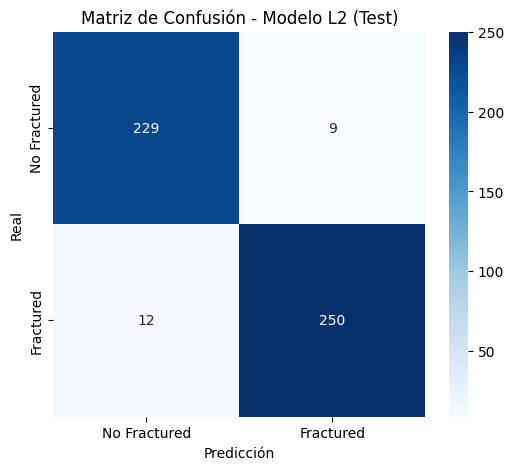

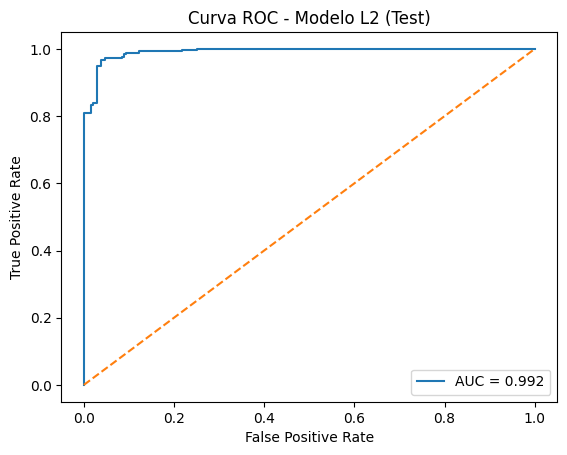

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

test_data.reset()

y_pred_prob = modelo_L2.predict(test_data)
y_pred_prob = y_pred_prob.ravel()

y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_data.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=['No Fractured', 'Fractured']
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fractured','Fractured'],
            yticklabels=['No Fractured','Fractured'])

plt.title("Matriz de Confusión - Modelo L2 (Test)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo L2 (Test)")
plt.legend()
plt.show()

## MODELO 4

In [ ]:
# Modelo con Dropout
model_4 = Sequential([
    Input(shape=(128, 128, 1)),
    Flatten(),

    Dense(512, activation='relu'),
    Dense(256, activation='relu'),

    Dropout(0.1),

    Dense(128, activation='relu'),

    Dense(1, activation='sigmoid')
])

model_4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Entrenamiento
history_4 = model_4.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
from tensorflow.keras.models import load_model
import pickle

ruta_guardado = "/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1/"

modelo_Dropout = load_model(ruta_guardado + "modelo_Dropout.h5")

with open(ruta_guardado + "history_Dropout.pkl", "rb") as f:
    history_Dropout_dict = pickle.load(f)

class History:
    def __init__(self, history):
        self.history = history

history_Dropout = History(history_Dropout_dict)

modelo_Dropout.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,553,475 (32.63 MB)

 Trainable params: 8,553,473 (32.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Mejor val_loss: 0.1290
Mejor val_accuracy: 0.9769
 4/13 ━━━━━━━━━━━━━━━━━━━━ 5s 564ms/step

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 551ms/step
              precision    recall  f1-score   support

No Fractured       0.98      0.92      0.95       337
   Fractured       0.95      0.99      0.97       486

    accuracy                           0.96       823
   macro avg       0.96      0.95      0.96       823
weighted avg       0.96      0.96      0.96       823



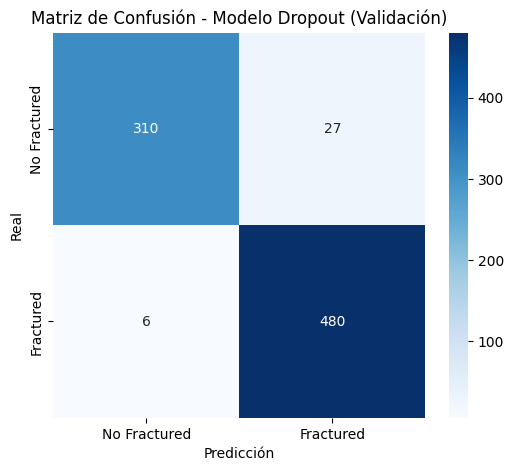

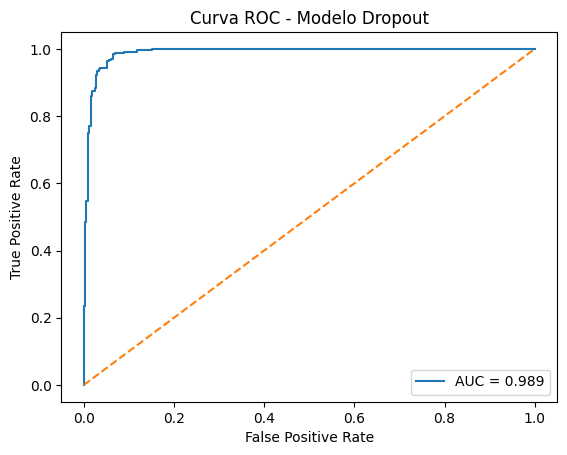

In [ ]:
from sklearn.metrics import (roc_curve, auc, precision_score, recall_score,
                             f1_score, accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

best_val_loss = np.min(history_Dropout.history['val_loss'])
best_val_acc = np.max(history_Dropout.history['val_accuracy'])
print(f"Mejor val_loss: {best_val_loss:.4f}")
print(f"Mejor val_accuracy: {best_val_acc:.4f}")

y_pred_prob = modelo_Dropout.predict(val_data)
y_pred_prob = y_pred_prob.ravel()

y_pred = (y_pred_prob > 0.5).astype(int)
y_true = val_data.classes

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = accuracy_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_pred_prob)

print(classification_report(
    y_true,
    y_pred,
    target_names=['No Fractured', 'Fractured']
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fractured','Fractured'],
            yticklabels=['No Fractured','Fractured'])

plt.title("Matriz de Confusión - Modelo Dropout (Validación)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo Dropout")
plt.legend()
plt.show()

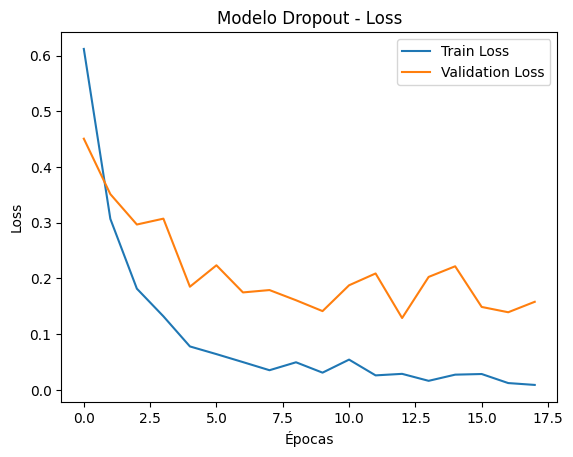

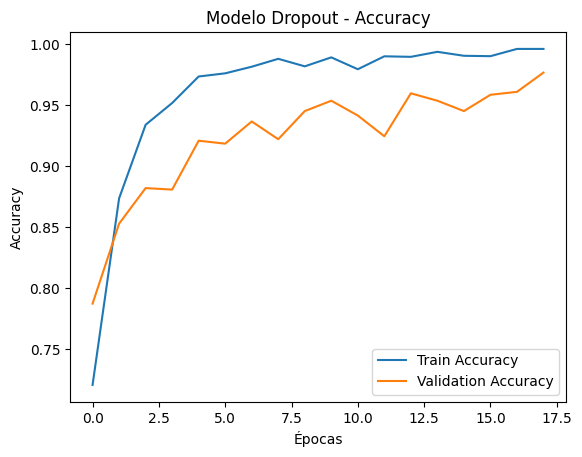

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure()
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f"{title} - Loss")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history_Dropout, "Modelo Dropout")

8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 559ms/step
              precision    recall  f1-score   support

No Fractured       0.97      0.97      0.97       238
   Fractured       0.97      0.98      0.97       262

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



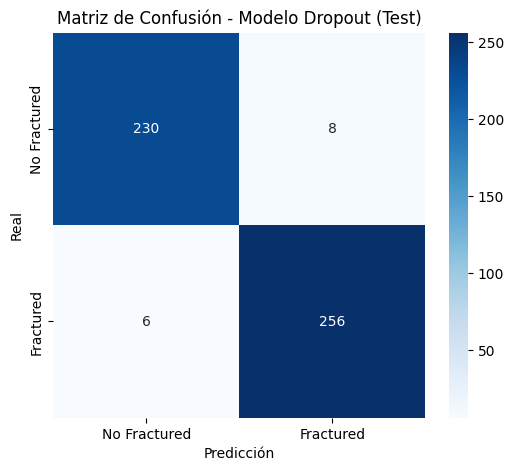

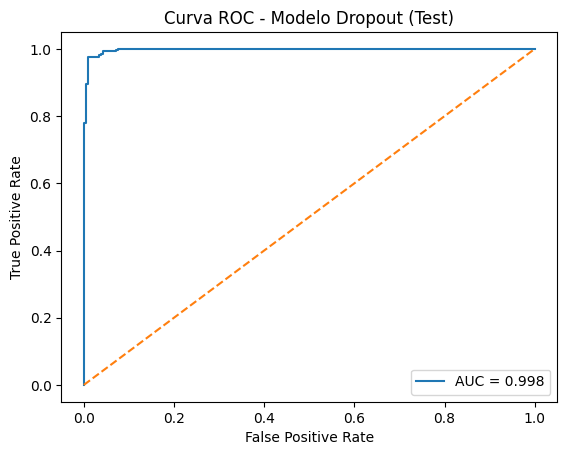

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

test_data.reset()

y_pred_prob = modelo_Dropout.predict(test_data)
y_pred_prob = y_pred_prob.ravel()

y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_data.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=['No Fractured', 'Fractured']
))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Fractured','Fractured'],
            yticklabels=['No Fractured','Fractured'])

plt.title("Matriz de Confusión - Modelo Dropout (Test)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo Dropout (Test)")
plt.legend()
plt.show()

## MODELO 5

In [ ]:
input_dim = x_train.shape[1]

model_5 = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(2, activation='softmax')
])

# Compilación con SGD (clave)
model_5.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop_5 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("🚀 Entrenando Modelo 5 (SGD)...\n")

historial_modelo_5 = model_5.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_val, y_val),
    epochs=35,
    batch_size=32,
    callbacks=[early_stop_5],
    verbose=1
)

print("\n✅ Entrenamiento finalizado")

In [ ]:
ruta_modelo_5 = ruta_base + 'modelo_5_fracturas.keras'
model_5.save(ruta_modelo_5)

print(f"💾 Modelo 5 guardado en:\n{ruta_modelo_5}")

💾 Modelo 5 guardado en:
/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 modelo_5_fracturas.keras


In [ ]:
ruta_modelo_5 = '/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 modelo_5_fracturas.keras'

model_5 = load_model(ruta_modelo_5)

print("✅ Modelo 5 cargado correctamente")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

🔍 Evaluación - Modelo 5
              precision    recall  f1-score   support

           0       0.86      0.84      0.85       268
           1       0.83      0.84      0.84       238

    accuracy                           0.84       506
   macro avg       0.84      0.84      0.84       506
weighted avg       0.84      0.84      0.84       506

F1 Score: 0.8358
ROC AUC: 0.9231


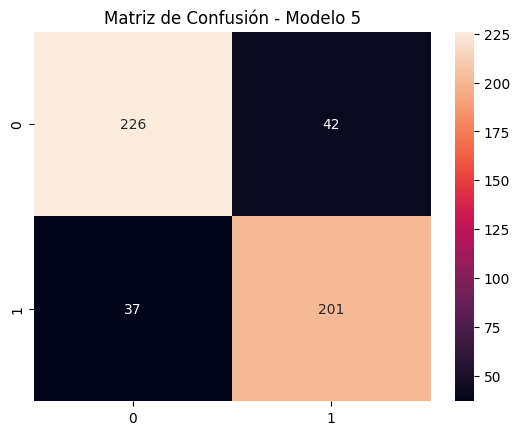

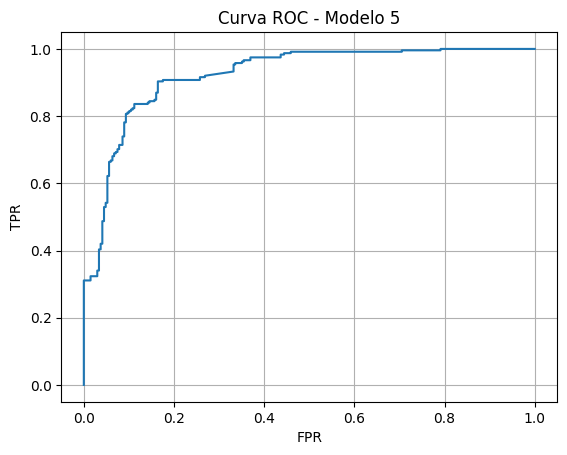

In [ ]:
evaluar_modelo(model_5, x_test, y_test, "Modelo 5")

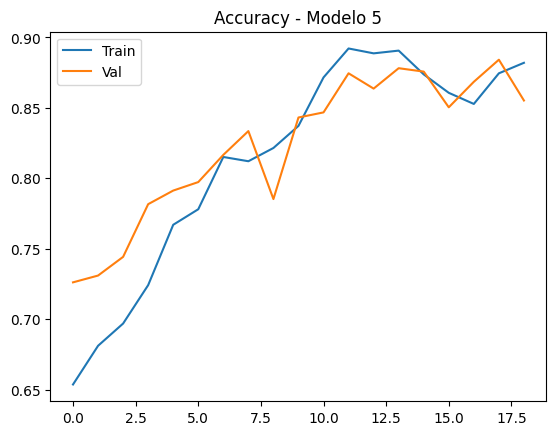

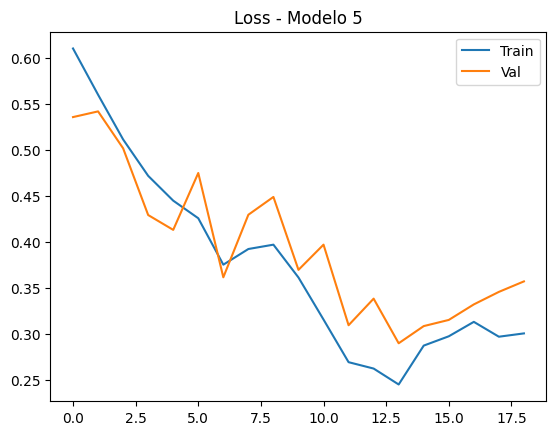

In [ ]:
# Accuracy
plt.plot(historial_modelo_5.history['accuracy'], label='Train')
plt.plot(historial_modelo_5.history['val_accuracy'], label='Val')
plt.title('Accuracy - Modelo 5')
plt.legend()
plt.show()

# Loss
plt.plot(historial_modelo_5.history['loss'], label='Train')
plt.plot(historial_modelo_5.history['val_loss'], label='Val')
plt.title('Loss - Modelo 5')
plt.legend()
plt.show()

## MODELO 6

In [ ]:
model_6 = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(512),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(128),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(2, activation='softmax')
])

model_6.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop_6 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("🚀 Entrenando Modelo 5 (SGD)...\n")

historial_modelo_6 = model_6.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_val, y_val),
    epochs=35,
    batch_size=32,
    callbacks=[early_stop_6],
    verbose=1
)

print("\n✅ Entrenamiento finalizado")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


🚀 Entrenando Modelo 5 (SGD)...

Epoch 1/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 42s 132ms/step - accuracy: 0.6896 - loss: 0.6975 - val_accuracy: 0.7431 - val_loss: 0.5823
Epoch 2/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 42s 145ms/step - accuracy: 0.7750 - loss: 0.5119 - val_accuracy: 0.8347 - val_loss: 0.4782
Epoch 3/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 40s 140ms/step - accuracy: 0.8161 - loss: 0.4265 - val_accuracy: 0.8504 - val_loss: 0.4525
Epoch 4/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 40s 140ms/step - accuracy: 0.8359 - loss: 0.3746 - val_accuracy: 0.8625 - val_loss: 0.3922
Epoch 5/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 40s 137ms/step - accuracy: 0.8642 - loss: 0.3276 - val_accuracy: 0.8878 - val_loss: 0.3750
Epoch 6/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 41s 138ms/step - accuracy: 0.8781 - loss: 0.2984 - val_accuracy: 0.8854 - val_loss: 0.3458
Epoch 7/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 41s 139ms/step - accuracy: 0.8907 - loss: 0.2745 - val_accuracy: 0.8866 - val_loss: 0.3796
Epoch 8/35
289/289 ━━━━━━━━━━━━━━━━━━━━ 41s 140ms/s

In [ ]:
ruta_modelo_6 = ruta_base + 'modelo_6_fracturas.keras'
model_6.save(ruta_modelo_6)

print(f"💾 Modelo 6 guardado en:\n{ruta_modelo_6}")

💾 Modelo 6 guardado en:
/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 modelo_6_fracturas.keras


In [ ]:
ruta_modelo_6 = '/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/Proyecto 1 modelo_6_fracturas.keras'

model_6 = load_model(ruta_modelo_6)

print("✅ Modelo 6 cargado correctamente")

✅ Modelo 6 cargado correctamente


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

🔍 Evaluación - Modelo 6
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       268
           1       0.90      0.95      0.92       238

    accuracy                           0.92       506
   macro avg       0.92      0.93      0.92       506
weighted avg       0.93      0.92      0.92       506

F1 Score: 0.9221
ROC AUC: 0.9869


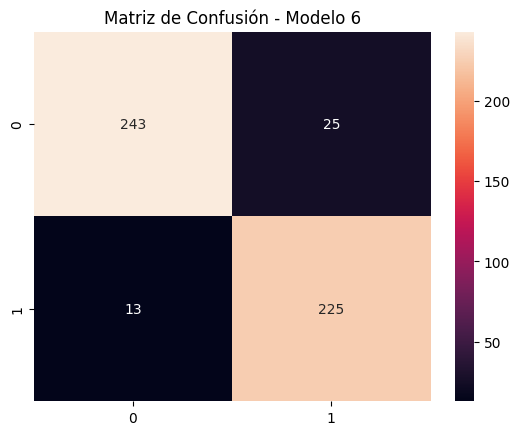

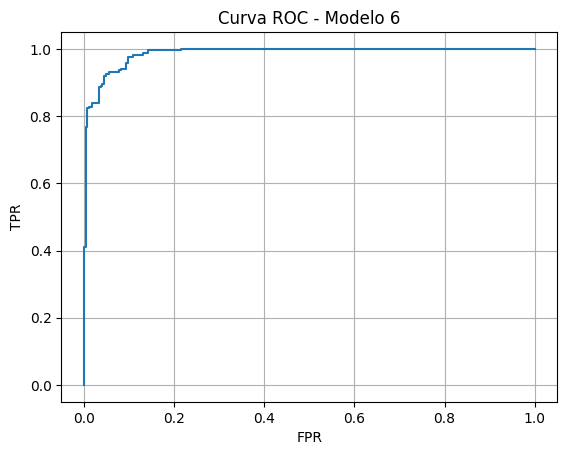

In [ ]:
evaluar_modelo(model_6, x_test, y_test, "Modelo 6")

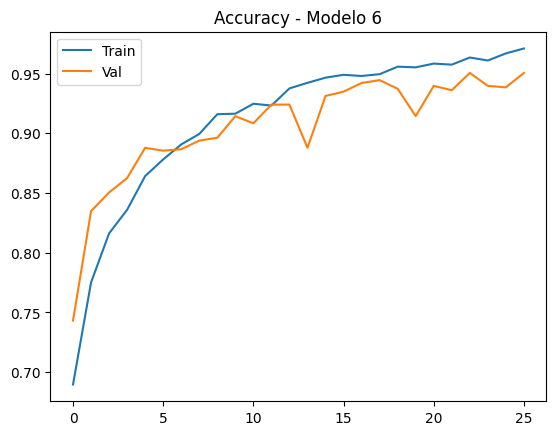

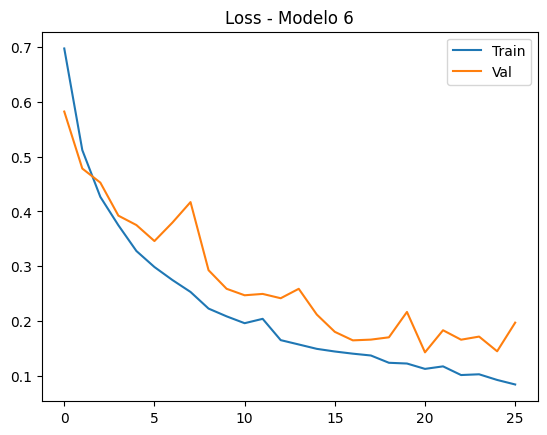

In [ ]:
# Accuracy
plt.plot(historial_modelo_6.history['accuracy'], label='Train')
plt.plot(historial_modelo_6.history['val_accuracy'], label='Val')
plt.title('Accuracy - Modelo 6')
plt.legend()
plt.show()

# Loss
plt.plot(historial_modelo_6.history['loss'], label='Train')
plt.plot(historial_modelo_6.history['val_loss'], label='Val')
plt.title('Loss - Modelo 6')
plt.legend()
plt.show()